# This is a simple example of how to load and plot the provided data.

In [1]:
%pip install zarr
%pip install xarray
%pip install cftime
%pip install nc-time-axis


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import zarr
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xarray.conventions import decode_cf
import zipfile
import os



In [39]:
# Path to your zip file
zip_path = '/home/ovashishtha/private/cse151b/cse151b-spring2025-competition.zip'

# Directory where you want to extract files
extract_dir = '/home/ovashishtha/private/cse151b'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzip complete!")

Unzip complete!


In [2]:
# Load the data (update the path to the correct location)
data_path = "processed_data_cse151b_v2_corrupted_ssp245/processed_data_cse151b_v2_corrupted_ssp245.zarr"
data = xr.open_zarr(data_path, decode_times=True)

data

<xarray.Dataset> Size: 621MB
Dimensions:    (ssp: 4, time: 1021, latitude: 48, longitude: 72, x: 72, y: 48,
                member_id: 3)
Coordinates:
    lat        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * latitude   (latitude) float64 384B -89.05 -85.26 -81.47 ... 85.26 89.05
    lon        (x, y) float64 28kB dask.array<chunksize=(72, 48), meta=np.ndarray>
  * longitude  (longitude) float64 576B 1.25 6.25 11.25 ... 346.2 351.2 356.2
  * member_id  (member_id) int64 24B 0 1 2
  * ssp        (ssp) <U6 96B 'ssp126' 'ssp245' 'ssp370' 'ssp585'
  * time       (time) object 8kB 2015-01-15 00:00:00 ... 2100-01-15 00:00:00
  * x          (x) float64 576B 1.875 6.875 11.88 16.88 ... 346.9 351.9 356.9
  * y          (y) float64 384B -88.59 -84.82 -81.05 ... 81.05 84.82 88.59
Data variables:
    BC         (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    CH4        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    CO2        (ssp, time) float64 33kB dask.array<chunksize=(1, 24), meta=np.ndarray>
    SO2        (ssp, time, latitude, longitude) float64 113MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    pr         (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
    rsdt       (ssp, time, y, x) float32 56MB dask.array<chunksize=(1, 24, 48, 72), meta=np.ndarray>
    tas        (ssp, time, member_id, y, x) float32 169MB dask.array<chunksize=(1, 24, 1, 48, 72), meta=np.ndarray>
Attributes:
    original_member_ids:  ['r10i1p1f1', 'r11i1p1f1', 'r4i1p1f1']
    precipitation_units:  mm/day (converted from kg m-2 s-1)
    source:               CMIP6 data processed for CSE151B
    ssp:                  ssp126

## Plot a few snapshots of temperature and precipitation (first, middle, and last)

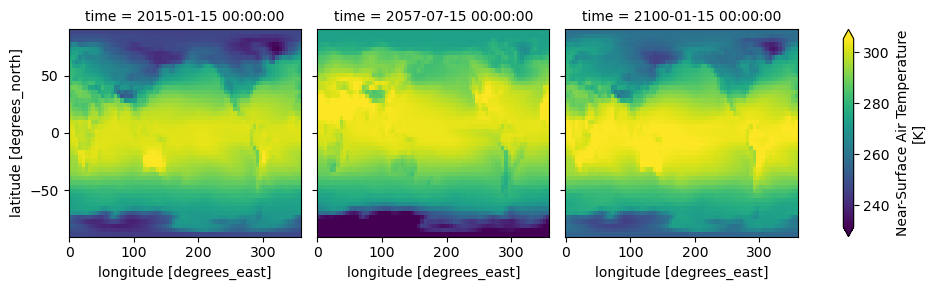

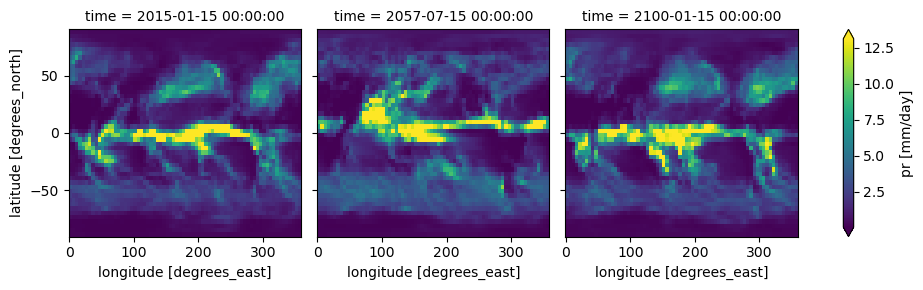

In [3]:
data_subset = data.isel(time=[0, data.time.size // 2, -1]).sel(ssp="ssp370", member_id=0)
data_subset.tas.plot(col="time", x="x", y="y", robust=True)
data_subset.pr.plot(col="time", x="x", y="y", robust=True)

In [5]:
print(global_mean_data.coords)
print(global_mean_data.coords['time'].dtype)

NameError: name 'global_mean_data' is not defined

# Plot the time series of global mean temperature and precipitation

Note that we do not plot the SSP245 scenario here, as it is corrupted in the provided data.

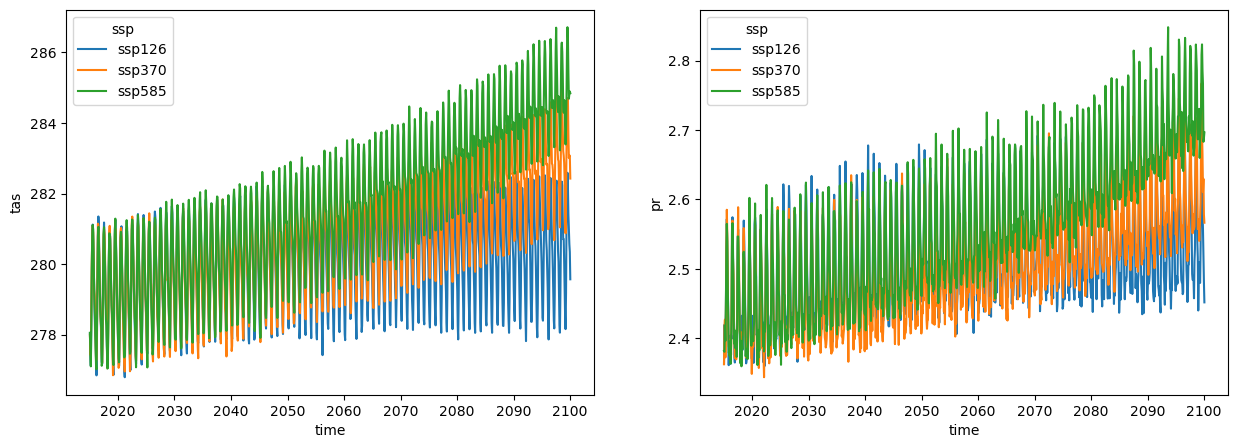

In [11]:
# Extract the cftime time values
global_mean_data = data.sel(ssp=["ssp126", "ssp370", "ssp585"]).mean(dim=["x", "y", "member_id"])

# global_mean_data = global_mean_data.assign_coords(
#     time=pd.to_datetime(global_mean_data.coords['time'].values)
# )
time_vals = global_mean_data.coords['time'].values

# Convert each cftime datetime to a string, then to pd.Timestamp
time_converted = [pd.Timestamp(t.strftime('%Y-%m-%d %H:%M:%S')) for t in time_vals]



# global_mean_data = data.sel(ssp=["ssp126", "ssp370", "ssp585"]).mean(dim=["x", "y", "member_id"])
global_mean_data = global_mean_data.assign_coords(time=time_converted)


# Fix time coordinate BEFORE plotting
global_mean_data = global_mean_data.assign_coords(
    time=pd.to_datetime(global_mean_data.coords['time'].values)
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
global_mean_data.tas.plot(label="Temperature", ax=ax[0], hue="ssp")
global_mean_data.pr.plot(label="Precipitation", ax=ax[1], hue="ssp")


# Plot the (global mean) time series of climate forcings

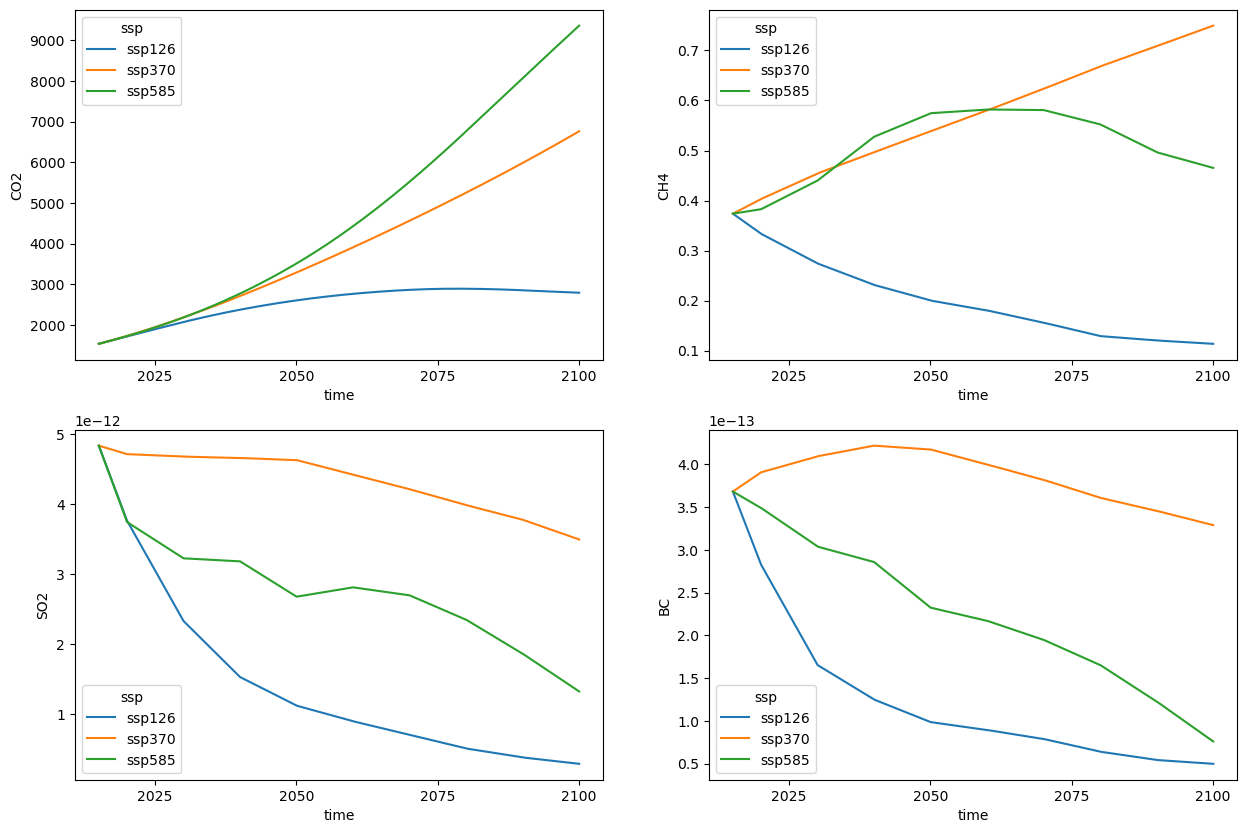

In [12]:
global_mean_data = data.sel(ssp=["ssp126", "ssp370", "ssp585"]).mean(dim=["longitude", "latitude", "member_id"]) 
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
global_mean_data.CO2.plot(ax=axes[0], hue="ssp")
global_mean_data.CH4.plot(ax=axes[1], hue="ssp")
global_mean_data.SO2.plot(ax=axes[2], hue="ssp")
_ = global_mean_data.BC.plot(ax=axes[3], hue="ssp")

In [13]:
data = data.sel(ssp=["ssp126", "ssp370", "ssp585"])

# Drop ssp245
data_filtered = data.sel(ssp=["ssp126", "ssp370", "ssp585"])

# Check overall shape
print("Dataset dimensions:", data_filtered.dims)

# If you’ve split into train/test already
print("Train size:", train_data.sizes if "train_data" in locals() else "Not split yet")
print("Test size:", test_data.sizes if "test_data" in locals() else "Not split yet")

# Spatial dimensions
print("Spatial dimensions (x, y):", data_filtered.sizes["x"], data_filtered.sizes["y"])



Dataset dimensions: FrozenMappingWarningOnValuesAccess({'ssp': 3, 'time': 1021, 'latitude': 48, 'longitude': 72, 'x': 72, 'y': 48, 'member_id': 3})
Train size: Not split yet
Test size: Not split yet
Spatial dimensions (x, y): 72 48


In [16]:
tas = data_filtered['tas']
pr = data_filtered['pr']

print("Temperature (tas): min = ", tas.min().compute().item(),
      " max = ", tas.max().compute().item(),
      " mean = ", tas.mean().compute().item(),
      " std = ", tas.std().compute().item())

print("Precipitation (pr): min = ", pr.min().compute().item(),
      " max = ", pr.max().compute().item(),
      " mean = ", pr.mean().compute().item(),
      " std = ", pr.std().compute().item())


Temperature (tas): min =  205.09869384765625  max =  320.86297607421875  mean =  280.7923278808594  std =  20.935701370239258
Precipitation (pr): min =  0.0  max =  70.12953186035156  mean =  2.525977611541748  std =  2.977147340774536


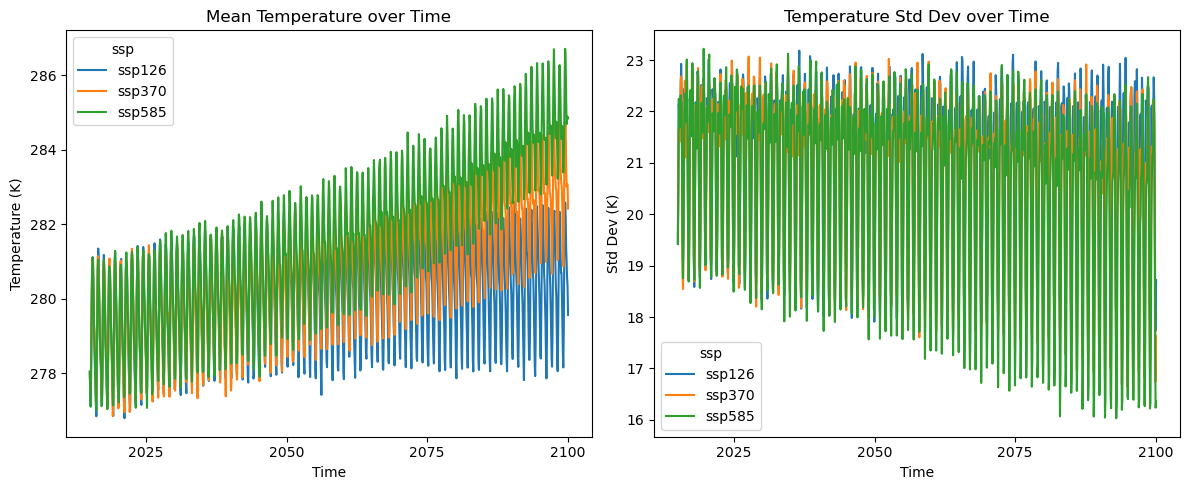

In [18]:
tas_mean = tas.mean(dim=["x", "y", "member_id"])
tas_std = tas.std(dim=["x", "y", "member_id"])

pr_mean = pr.mean(dim=["x", "y", "member_id"])
pr_std = pr.std(dim=["x", "y", "member_id"])

import matplotlib.pyplot as plt

# Plot mean and std of tas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
tas_mean.plot.line(hue='ssp')
plt.title("Mean Temperature over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (K)")

plt.subplot(1, 2, 2)
tas_std.plot.line(hue='ssp')
plt.title("Temperature Std Dev over Time")
plt.xlabel("Time")
plt.ylabel("Std Dev (K)")

plt.tight_layout()
plt.show()



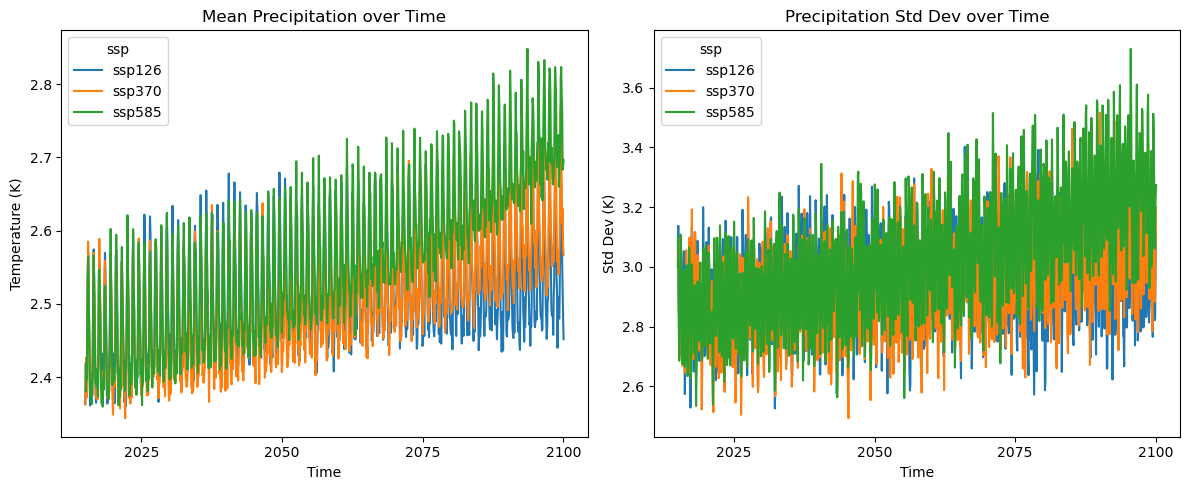

In [19]:
# Plot mean and std of pr
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pr_mean.plot.line(hue='ssp')
plt.title("Mean Precipitation over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (K)")

plt.subplot(1, 2, 2)
pr_std.plot.line(hue='ssp')
plt.title("Precipitation Std Dev over Time")
plt.xlabel("Time")
plt.ylabel("Std Dev (K)")

plt.tight_layout()
plt.show()


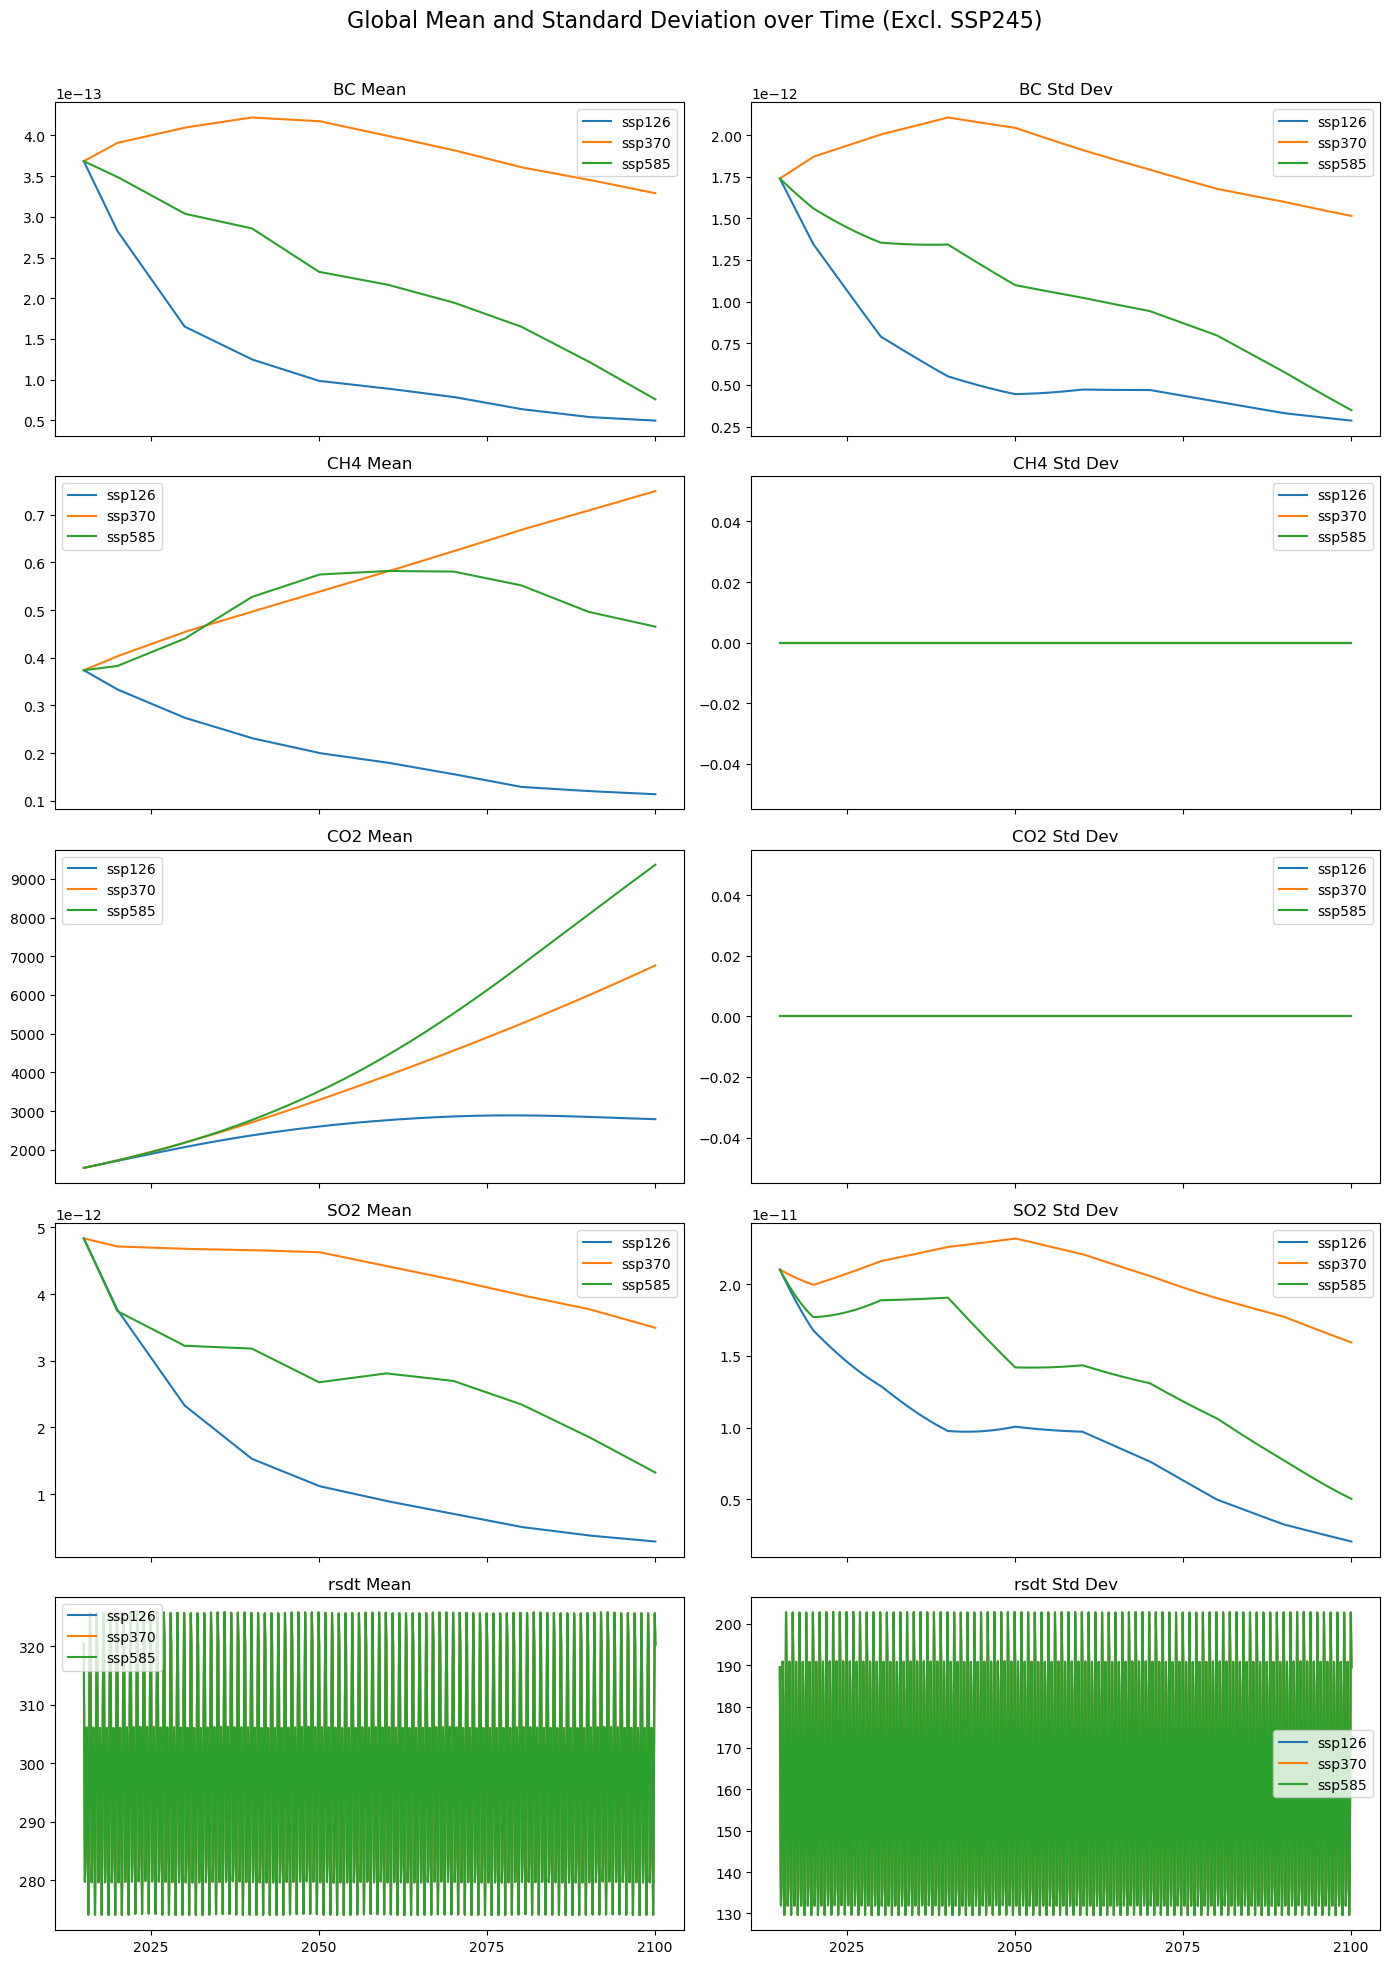

In [21]:
variables_to_plot = ['BC', 'CH4', 'CO2', 'SO2', 'rsdt']
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(14, 20), sharex=True)
fig.suptitle("Global Mean and Standard Deviation over Time (Excl. SSP245)", fontsize=16)

for i, var in enumerate(variables_to_plot):
    da = data_filtered[var]

    # Reduce spatial dimensions if present
    spatial_dims = [dim for dim in ['lat', 'latitude', 'lon', 'longitude', 'x', 'y'] if dim in da.dims]
    da_mean = da.mean(dim=spatial_dims).compute()
    da_std = da.std(dim=spatial_dims).compute()

    # Plot mean
    for ssp in da.coords['ssp'].values:
        axes[i, 0].plot(da_mean.sel(ssp=ssp).coords['time'], da_mean.sel(ssp=ssp), label=f"{ssp}")
    axes[i, 0].set_title(f"{var} Mean")
    axes[i, 0].legend()

    # Plot std
    for ssp in da.coords['ssp'].values:
        axes[i, 1].plot(da_std.sel(ssp=ssp).coords['time'], da_std.sel(ssp=ssp), label=f"{ssp}")
    axes[i, 1].set_title(f"{var} Std Dev")
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

['ssp126' 'ssp370' 'ssp585']


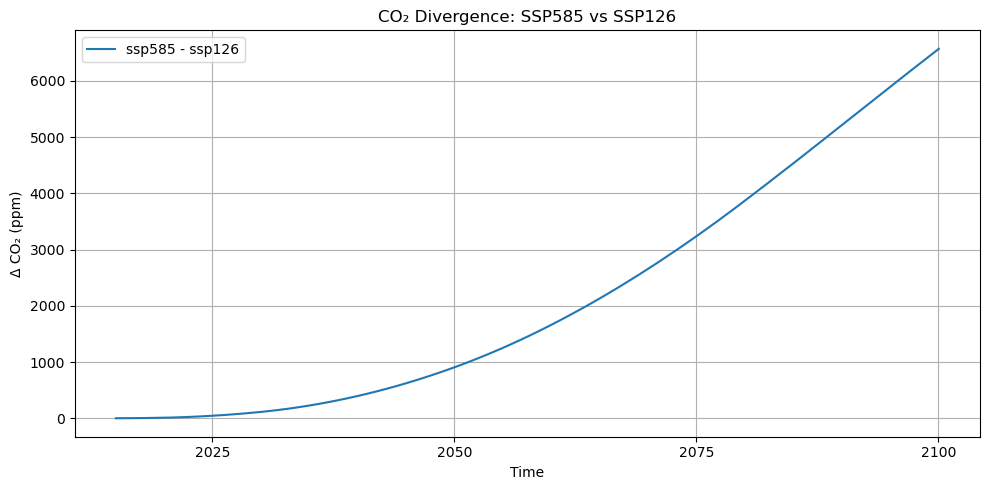

In [24]:
##ssp divergence plot
import matplotlib.pyplot as plt

# Check your SSP names first if unsure
print(data['CO2'].coords['ssp'].values)

# Correct variable selection
co2_ssp585 = data['CO2'].sel(ssp='ssp585')  # High emissions
co2_ssp126 = data['CO2'].sel(ssp='ssp126')  # Low emissions

# Compute the divergence
co2_diff = co2_ssp585 - co2_ssp126

# Plot it
plt.figure(figsize=(10, 5))
co2_diff.plot(label='ssp585 - ssp126')
plt.title("CO₂ Divergence: SSP585 vs SSP126")
plt.xlabel("Time")
plt.ylabel("Δ CO₂ (ppm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




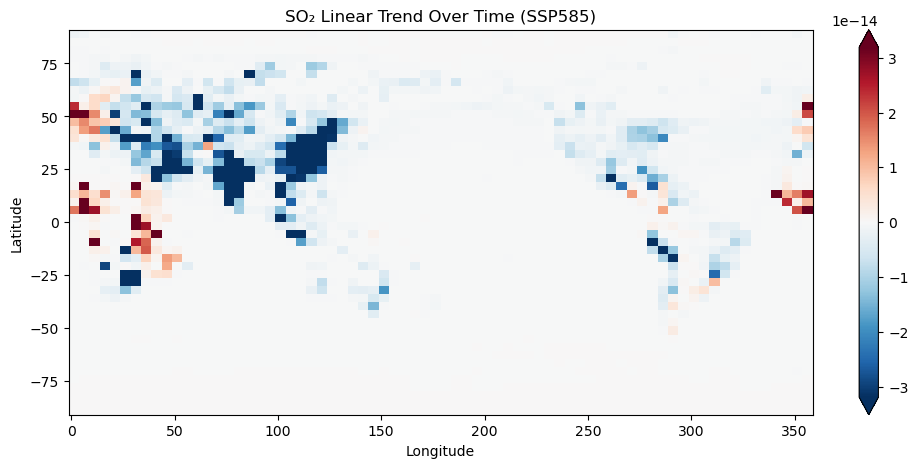

In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def linear_trend_over_time(da):
    time_numeric = xr.DataArray(np.arange(da.sizes['time']), dims='time')
    x = time_numeric - time_numeric.mean()
    y = da - da.mean('time')
    slope = (x * y).mean('time') / (x**2).mean()
    return slope

# Select data for one SSP scenario
so2 = data['SO2'].sel(ssp='ssp585')  # adjust this to your actual SSP coordinate values

# Compute slope per pixel (lat, lon)
so2_trend = linear_trend_over_time(so2)

# Plot the spatial trend
plt.figure(figsize=(12, 5))
so2_trend.plot(cmap='RdBu_r', robust=True)
plt.title("SO₂ Linear Trend Over Time (SSP585)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


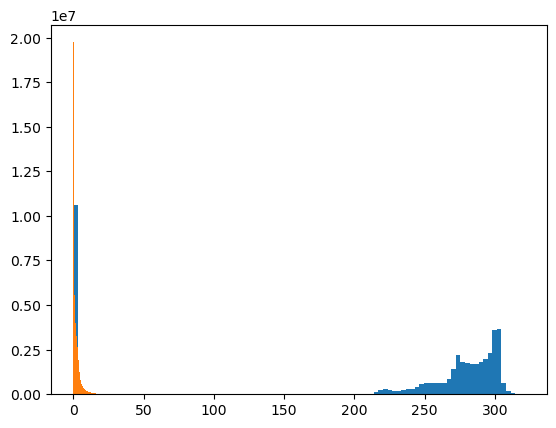

In [35]:
flat_tas_data = np.array(data.tas).flatten()
flat_pr_data = np.array(data.pr).flatten()

plt.hist(flat_tas_data, bins=np.linspace(flat_tas_data.min(), flat_tas_data.max(), 100))
plt.hist(flat_pr_data, bins=np.linspace(flat_pr_data.min(), flat_pr_data.max(), 100))
plt.show()

/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/opt/conda/lib/python3.11/site-packages/numpy/core/_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


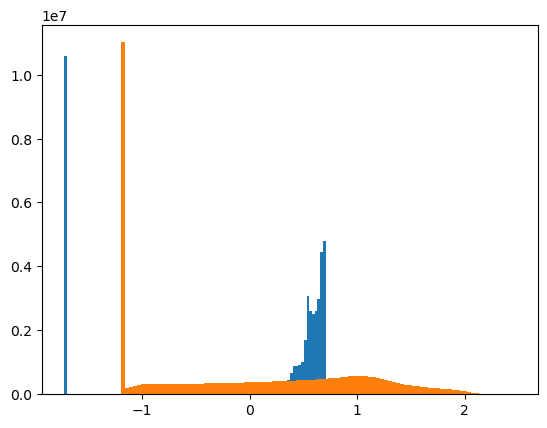

In [39]:
from sklearn.preprocessing import PowerTransformer

pt_pr = PowerTransformer(method='yeo-johnson')  
pt_ta = PowerTransformer(method='yeo-johnson')  
norm_pr = pt_pr.fit_transform(flat_tas_data.reshape(-1, 1))
norm_tas = pt_pr.fit_transform(flat_pr_data.reshape(-1, 1))

plt.hist(norm_pr, bins=np.linspace(norm_pr.min(), norm_pr.max(), 100))
plt.hist(norm_tas, bins=np.linspace(norm_tas.min(), norm_tas.max(), 100))
plt.show()

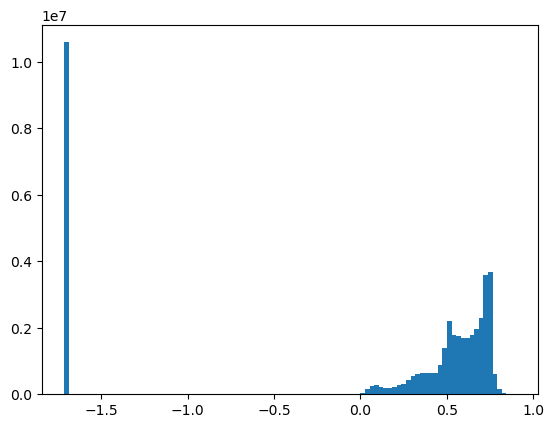

In [21]:
tas = np.array(data.tas).flatten()
tas = (tas - np.mean(tas)) / np.std(tas)

plt.hist(tas, bins=np.linspace(tas.min(), tas.max(), 100))
plt.show()

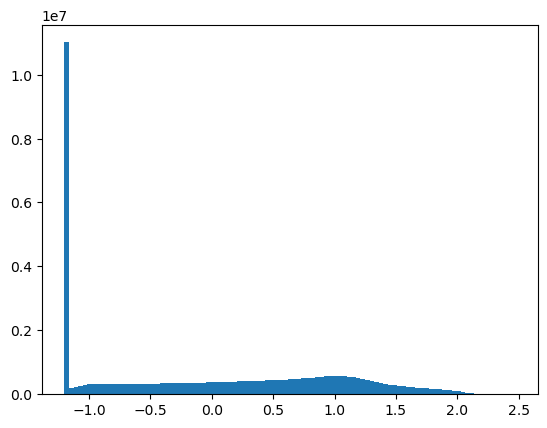

In [26]:
prs = np.array(data.pr).flatten()
prs = pt.fit_transform(prs.reshape(-1, 1)).flatten()

plt.hist(prs, bins=np.linspace(prs.min(), prs.max(), 100))
plt.show()

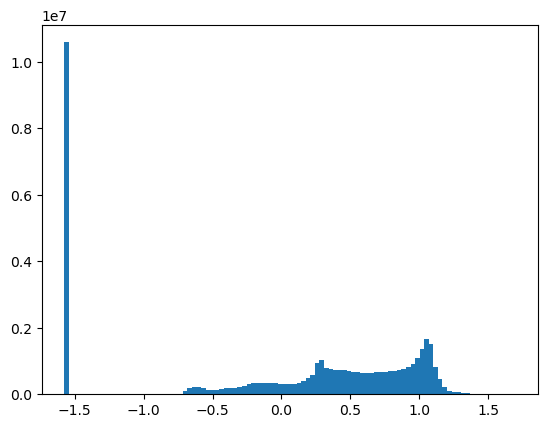

In [25]:
plt.hist(data_transformed, bins=np.linspace(data_transformed.min(), data_transformed.max(), 100))
plt.show()